In [1]:
# OT/ICS Intrusion Detection – HAI Turbine Testbed (Autoencoder)

In [2]:
from tqdm.auto import tqdm

libs = [
    ("polars",       lambda: __import__('polars')),
    ("numpy",        lambda: __import__('numpy')),
    ("pathlib",      lambda: __import__('pathlib')),
    ("sklearn",      lambda: __import__('sklearn')),
    ("torch",        lambda: __import__('torch')),
    ("torch.nn",     lambda: __import__('torch.nn')),
    ("torch.optim",  lambda: __import__('torch.optim')),
    ("matplotlib",   lambda: __import__('matplotlib')),
    ("seaborn",      lambda: __import__('seaborn')),
    ("joblib",       lambda: __import__('joblib')),
]

with tqdm(libs, desc="Loading libraries", unit="lib", leave=True) as pbar:
    for name, _ in pbar:
        pbar.set_postfix(lib=name)

import polars as pl
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Setup complete. Device: {device}")

C:\Users\User\ai-cybersecurity-portfolio\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading libraries:   0%|          | 0/10 [00:00<?, ?lib/s]


Loading libraries:   0%|          | 0/10 [00:00<?, ?lib/s, lib=polars]


Loading libraries:   0%|          | 0/10 [00:00<?, ?lib/s, lib=numpy] 


Loading libraries:   0%|          | 0/10 [00:00<?, ?lib/s, lib=pathlib]

...


Loading libraries:   0%|          | 0/10 [00:00<?, ?lib/s, lib=matplotlib] 


Loading libraries:   0%|          | 0/10 [00:00<?, ?lib/s, lib=seaborn]   


Loading libraries:   0%|          | 0/10 [00:00<?, ?lib/s, lib=joblib] 


Loading libraries: 100%|██████████| 10/10 [00:00<00:00, 2181.13lib/s, lib=joblib]

✅ Setup complete. Device: cpu


In [3]:
from tqdm.auto import tqdm

files = [
    ('train1.csv', 'train1'),
    ('train2.csv', 'train2'),
    ('test1.csv',  'test1'),
    ('test2.csv',  'test2'),
]

dfs = {}
for fname, key in tqdm(files, desc="Loading HAI files", unit="file", leave=True):
    dfs[key] = pl.read_csv(DATA_RAW / fname, separator=';', ignore_errors=True)
    tqdm.write(f"   ✓ {fname} — {len(dfs[key]):,} rows")

train1, train2, test1, test2 = dfs['train1'], dfs['train2'], dfs['test1'], dfs['test2']

print("⏳ Combining files...")
df = pl.concat([train1, train2, test1, test2], how='diagonal_relaxed')

print(f"\n✅ Data loaded.")
print(f"   Total rows   : {len(df):,}")
print(f"   Columns      : {df.columns[:10]}…")
print(f"   Attack values: {df['attack'].unique().to_list()}")
df.head(2)


Loading HAI files:   0%|          | 0/4 [00:00<?, ?file/s]


Loading HAI files:   0%|          | 0/4 [00:00<?, ?file/s]


Loading HAI files:  25%|██▌       | 1/4 [00:00<00:00,  7.27file/s]

   ✓ train1.csv — 309,600 rows



Loading HAI files:  25%|██▌       | 1/4 [00:00<00:00,  7.27file/s]

...

   ✓ test1.csv — 291,600 rows



Loading HAI files:  75%|███████▌  | 3/4 [00:00<00:00,  7.81file/s]


Loading HAI files: 100%|██████████| 4/4 [00:00<00:00,  8.64file/s]

   ✓ test2.csv — 153,000 rows
⏳ Combining files...

✅ Data loaded.
   Total rows   : 995,400
   Columns      : ['time', 'P1_B2004', 'P1_B2016', 'P1_B3004', 'P1_B3005', 'P1_B4002', 'P1_B4005', 'P1_B400B', 'P1_B4022', 'P1_FCV01D']…
   Attack values: [0, 1]


time,P1_B2004,P1_B2016,P1_B3004,P1_B3005,P1_B4002,P1_B4005,P1_B400B,P1_B4022,P1_FCV01D,P1_FCV01Z,P1_FCV02D,P1_FCV02Z,P1_FCV03D,P1_FCV03Z,P1_FT01,P1_FT01Z,P1_FT02,P1_FT02Z,P1_FT03,P1_FT03Z,P1_LCV01D,P1_LCV01Z,P1_LIT01,P1_PCV01D,P1_PCV01Z,P1_PCV02D,P1_PCV02Z,P1_PIT01,P1_PIT02,P1_TIT01,P1_TIT02,P2_24Vdc,P2_Auto,P2_Emgy,P2_On,P2_SD01,P2_SIT01,P2_TripEx,P2_VT01e,P2_VXT02,P2_VXT03,P2_VYT02,P2_VYT03,P3_LCP01D,P3_LCV01D,P3_LH,P3_LL,P3_LT01,P4_HT_FD,P4_HT_LD,P4_HT_PO,P4_HT_PS,P4_LD,P4_ST_FD,P4_ST_LD,P4_ST_PO,P4_ST_PS,P4_ST_PT01,P4_ST_TT01,attack,attack_P1,attack_P2,attack_P3
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64
"""2019-09-11 20:00:00""",0.0983,1.0702,399.2321,1110.3986,32.0,0.0,28.9981,35.7395,0.0,0.2838,100.0,95.5215,53.785,55.0323,132.9803,711.2531,5.188,29.9914,312.0803,1112.1606,19.6892,19.2886,396.6266,35.21,36.3403,12,12.0102,1.0843,0.2084,36.0779,37.3596,28.0221,1,0,1,20,815,0,11.8983,-3.2879,-1.2942,0.2115,1.8135,1167,12767,70,10,28.9352,0.0005,64.4604,57.8704,0,395.0195,-0.0004,330.6568,328.9388,50.9871,9973,27629,0,0,0,0
"""2019-09-11 20:00:01""",0.0983,1.0699,399.2321,1110.3986,32.0,0.0,29.9914,35.7388,0.0,0.2838,100.0,95.4529,53.6683,55.0323,130.31,692.3841,6.3324,27.0122,313.6062,1112.7983,19.6654,19.2886,396.6266,35.2091,36.3403,12,12.0102,1.0828,0.2138,36.0931,37.3596,28.0273,1,0,1,20,815,0,11.7277,-3.9746,-1.3099,1.0309,2.4783,1107,12911,70,10,28.9352,0.0005,64.7208,58.4853,0,398.3109,-0.0012,330.2228,329.3728,50.9871,9973,27629,0,0,0,0


In [4]:
from tqdm.auto import tqdm

steps = ["find label column", "cast labels", "select features", "fill nulls", "scale features"]
with tqdm(total=len(steps), desc="Preparing features", unit="step", leave=True) as pbar:

    label_col = 'attack' if 'attack' in df.columns else 'label'
    if label_col not in df.columns:
        for c in df.columns:
            if 'attack' in c.lower() and 'type' not in c.lower():
                label_col = c; break
        else:
            raise ValueError("Could not find attack label column.")
    pbar.set_postfix(step=steps[0]); pbar.update(1)

    df = df.with_columns(pl.col(label_col).cast(pl.Int64).alias('is_attack'))
    pbar.set_postfix(step=steps[1]); pbar.update(1)

    # Exclude the label columns themselves ('attack', 'attack_P1/P2/P3') along with
    # 'is_attack' — leaving these in caused the model to see the ground-truth label
    # as an input "sensor" feature (always 0 during training on normal-only data),
    # which inflated attack-detection recall via leakage rather than real physics.
    label_cols = [c for c in df.columns if c == label_col or c.lower().startswith('attack')]
    feature_cols = [c for c in df.columns if c not in set(['is_attack', 'attack_type', 'time', 'timestamp'] + label_cols)]
    numeric_df = df.select(feature_cols).select(pl.all().cast(pl.Float32, strict=False))
    pbar.set_postfix(step=steps[2]); pbar.update(1)

    numeric_df = numeric_df.fill_null(strategy='mean')
    pbar.set_postfix(step=steps[3]); pbar.update(1)

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df.to_numpy())
    pbar.set_postfix(step=steps[4]); pbar.update(1)

print(f"✅ Feature matrix ready: {scaled_data.shape[0]:,} rows × {scaled_data.shape[1]} features")


Preparing features:   0%|          | 0/5 [00:00<?, ?step/s]


Preparing features:   0%|          | 0/5 [00:00<?, ?step/s, step=find label column]


Preparing features:  20%|██        | 1/5 [00:00<00:00, 59.55step/s, step=cast labels]


Preparing features:  40%|████      | 2/5 [00:00<00:00, 15.34step/s, step=select features]


Preparing features:  60%|██████    | 3/5 [00:00<00:00, 22.86step/s, step=select features]


Preparing features:  60%|██████    | 3/5 [00:00<00:00, 22.86step/s, step=fill nulls]     


Preparing features:  80%|████████  | 4/5 [00:00<00:00, 22.86step/s, step=scale features]


Preparing features: 100%|██████████| 5/5 [00:00<00:00,  5.73step/s, step=scale features]

✅ Feature matrix ready: 995,400 rows × 59 features


In [5]:
from tqdm.auto import tqdm

steps = ["normal/attack masks", "train/val split", "train tensor", "val tensor", "attack tensor"]
with tqdm(total=len(steps), desc="Building data splits", unit="step", leave=True) as pbar:

    normal_mask = (df['is_attack'] == 0).to_numpy()
    attack_mask = (df['is_attack'] == 1).to_numpy()
    X_normal = scaled_data[normal_mask]
    X_attack  = scaled_data[attack_mask]
    pbar.set_postfix(step=steps[0]); pbar.update(1)

    np.random.seed(SEED)
    perm = np.random.permutation(len(X_normal))
    train_size = int(len(X_normal) * 0.8)
    X_train = X_normal[perm[:train_size]]
    X_val   = X_normal[perm[train_size:]]
    pbar.set_postfix(step=steps[1]); pbar.update(1)

    t_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    pbar.set_postfix(step=steps[2]); pbar.update(1)

    t_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    pbar.set_postfix(step=steps[3]); pbar.update(1)

    t_attack = torch.tensor(X_attack, dtype=torch.float32).to(device)
    pbar.set_postfix(step=steps[4]); pbar.update(1)

print(f"✅ Splits ready — Normal: {len(X_normal):,}  |  Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Attack: {len(X_attack):,}")


Building data splits:   0%|          | 0/5 [00:00<?, ?step/s]


Building data splits:   0%|          | 0/5 [00:00<?, ?step/s, step=normal/attack masks]


Building data splits:  20%|██        | 1/5 [00:00<00:00,  4.51step/s, step=train/val split]


Building data splits:  40%|████      | 2/5 [00:00<00:00,  9.00step/s, step=train/val split]


Building data splits:  40%|████      | 2/5 [00:00<00:00,  9.00step/s, step=train tensor]   


Building data splits:  60%|██████    | 3/5 [00:00<00:00,  9.00step/s, step=val tensor]  


Building data splits:  80%|████████  | 4/5 [00:00<00:00,  9.00step/s, step=attack tensor]


Building data splits: 100%|██████████| 5/5 [00:00<00:00, 18.07step/s, step=attack tensor]

✅ Splits ready — Normal: 977,097  |  Train: 781,677  |  Val: 195,420  |  Attack: 18,303


In [6]:
from tqdm.auto import tqdm

steps = ["define encoder", "define decoder", "instantiate model", "move to device", "count params"]
with tqdm(total=len(steps), desc="Building Autoencoder", unit="step", leave=True) as pbar:

    class Autoencoder(nn.Module):
        def __init__(self, input_dim, encoding_dim=32):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 128), nn.ReLU(),
                nn.Linear(128, 64),        nn.ReLU(),
                nn.Linear(64, encoding_dim)
            )
            self.decoder = nn.Sequential(
                nn.Linear(encoding_dim, 64), nn.ReLU(),
                nn.Linear(64, 128),          nn.ReLU(),
                nn.Linear(128, input_dim)
            )
        def forward(self, x):
            return self.decoder(self.encoder(x))
    pbar.set_postfix(step=steps[0]); pbar.update(1)
    pbar.set_postfix(step=steps[1]); pbar.update(1)

    input_dim = X_train.shape[1]
    model = Autoencoder(input_dim, encoding_dim=32)
    pbar.set_postfix(step=steps[2]); pbar.update(1)

    model = model.to(device)
    pbar.set_postfix(step=steps[3]); pbar.update(1)

    total_params = sum(p.numel() for p in model.parameters())
    pbar.set_postfix(step=steps[4]); pbar.update(1)

print(f"✅ Model ready — Input: {input_dim}  |  Encoding: 32  |  Params: {total_params:,}")
print(model)


Building Autoencoder:   0%|          | 0/5 [00:00<?, ?step/s]


Building Autoencoder:   0%|          | 0/5 [00:00<?, ?step/s, step=define encoder]


Building Autoencoder:  20%|██        | 1/5 [00:00<00:00, 2046.00step/s, step=define decoder]


Building Autoencoder:  40%|████      | 2/5 [00:00<00:00, 752.61step/s, step=instantiate model]


Building Autoencoder:  60%|██████    | 3/5 [00:00<00:00, 821.50step/s, step=move to device]   


Building Autoencoder:  80%|████████  | 4/5 [00:00<00:00, 950.07step/s, step=count params]  


Building Autoencoder: 100%|██████████| 5/5 [00:00<00:00, 1060.94step/s, step=count params]

✅ Model ready — Input: 59  |  Encoding: 32  |  Params: 36,059
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=59, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=59, bias=True)
  )
)


In [7]:
from tqdm.auto import tqdm

epochs     = 50
batch_size = 256
lr         = 1e-3

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
dataset   = TensorDataset(t_train, t_train)
loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"⏳ Training Autoencoder — {epochs} epochs, {len(loader)} batches/epoch...")

model.train()
epoch_bar = tqdm(range(1, epochs + 1), desc="Training", unit="epoch", total=epochs, leave=True)
for epoch in epoch_bar:
    total_loss = 0
    for batch_x, _ in loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    epoch_bar.set_postfix(loss=f"{avg_loss:.6f}")
    if epoch % 10 == 0 or epoch == 1:
        print(f"   Epoch {epoch:>3}/{epochs}   loss={avg_loss:.6f}")

print(f"\n✅ Training complete. Final loss: {avg_loss:.6f}")

⏳ Training Autoencoder — 50 epochs, 3054 batches/epoch...



Training:   0%|          | 0/50 [00:00<?, ?epoch/s]


Training:   0%|          | 0/50 [00:11<?, ?epoch/s, loss=0.043914]


Training:   2%|▏         | 1/50 [00:11<09:39, 11.83s/epoch, loss=0.043914]

   Epoch   1/50   loss=0.043914


...


Training:  98%|█████████▊| 49/50 [11:13<00:13, 13.89s/epoch, loss=0.022750]


Training:  98%|█████████▊| 49/50 [11:27<00:13, 13.89s/epoch, loss=0.023914]


Training: 100%|██████████| 50/50 [11:27<00:00, 13.96s/epoch, loss=0.023914]


Training: 100%|██████████| 50/50 [11:27<00:00, 13.74s/epoch, loss=0.023914]

   Epoch  50/50   loss=0.023914

✅ Training complete. Final loss: 0.023914


In [8]:
from tqdm.auto import tqdm

model.eval()
with torch.no_grad():
    with tqdm(total=2, desc="Computing reconstruction errors", unit="set", leave=True) as pbar:
        val_recon    = model(t_val)
        val_errors   = torch.mean((val_recon - t_val) ** 2, dim=1).cpu().numpy()
        pbar.set_postfix(set="validation", samples=f"{len(val_errors):,}")
        pbar.update(1)

        attack_recon  = model(t_attack)
        attack_errors = torch.mean((attack_recon - t_attack) ** 2, dim=1).cpu().numpy()
        pbar.set_postfix(set="attack", samples=f"{len(attack_errors):,}")
        pbar.update(1)

print(f"\n✅ Reconstruction errors ready.")
print(f"   Normal error (mean) : {val_errors.mean():.6f}")
print(f"   Attack error (mean) : {attack_errors.mean():.6f}")


Computing reconstruction errors:   0%|          | 0/2 [00:00<?, ?set/s]


Computing reconstruction errors:   0%|          | 0/2 [00:00<?, ?set/s, samples=195,420, set=validation]


Computing reconstruction errors:  50%|█████     | 1/2 [00:00<00:00,  4.04set/s, samples=195,420, set=validation]


Computing reconstruction errors:  50%|█████     | 1/2 [00:00<00:00,  4.04set/s, samples=18,303, set=attack]     


Computing reconstruction errors: 100%|██████████| 2/2 [00:00<00:00,  7.46set/s, samples=18,303, set=attack]


✅ Reconstruction errors ready.
   Normal error (mean) : 0.003557
   Attack error (mean) : 34.142292


In [9]:
from tqdm.auto import tqdm

steps = ["compute threshold", "predict normal", "predict attack", "build labels", "classification report"]
with tqdm(total=len(steps), desc="Evaluating model", unit="step", leave=True) as pbar:

    threshold = np.percentile(val_errors, 95)
    pbar.set_postfix(step=steps[0]); pbar.update(1)

    pred_normal = (val_errors   > threshold).astype(int)
    pbar.set_postfix(step=steps[1]); pbar.update(1)

    pred_attack = (attack_errors > threshold).astype(int)
    pbar.set_postfix(step=steps[2]); pbar.update(1)

    y_true = np.concatenate([np.zeros(len(val_errors)), np.ones(len(attack_errors))])
    y_pred = np.concatenate([pred_normal, pred_attack])
    pbar.set_postfix(step=steps[3]); pbar.update(1)

    report = classification_report(y_true, y_pred, target_names=['Normal', 'Attack'])
    cm     = confusion_matrix(y_true, y_pred)
    pbar.set_postfix(step=steps[4]); pbar.update(1)

print(f"\n✅ Evaluation complete. Threshold: {threshold:.6f}")
print("\nClassification Report (0=normal, 1=attack):")
print(report)
print("Confusion Matrix:")
print(cm)


Evaluating model:   0%|          | 0/5 [00:00<?, ?step/s]


Evaluating model:   0%|          | 0/5 [00:00<?, ?step/s, step=compute threshold]


Evaluating model:  20%|██        | 1/5 [00:00<00:00, 167.50step/s, step=predict normal]


Evaluating model:  40%|████      | 2/5 [00:00<00:00, 309.03step/s, step=predict attack]


Evaluating model:  60%|██████    | 3/5 [00:00<00:00, 358.64step/s, step=build labels]  


Evaluating model:  80%|████████  | 4/5 [00:00<00:00, 22.64step/s, step=classification report]


Evaluating model: 100%|██████████| 5/5 [00:00<00:00, 28.04step/s, step=classification report]


Evaluating model: 100%|██████████| 5/5 [00:00<00:00, 27.91step/s, step=classification report]


✅ Evaluation complete. Threshold: 0.009223

Classification Report (0=normal, 1=attack):
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.97    195420
      Attack       0.61      0.84      0.71     18303

    accuracy                           0.94    213723
   macro avg       0.80      0.90      0.84    213723
weighted avg       0.95      0.94      0.95    213723

Confusion Matrix:
[[185649   9771]
 [  2870  15433]]



Saving results:   0%|          | 0/4 [00:00<?, ?step/s]

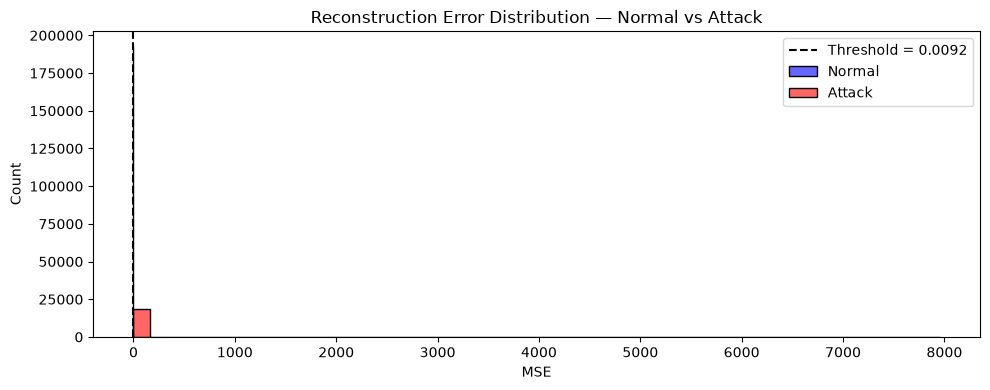


Saving results:   0%|          | 0/4 [00:01<?, ?step/s, step=render plot]


Saving results:  25%|██▌       | 1/4 [00:01<00:03,  1.26s/step, step=render plot]


Saving results:  25%|██▌       | 1/4 [00:01<00:03,  1.26s/step, step=save model] 


Saving results:  50%|█████     | 2/4 [00:01<00:02,  1.26s/step, step=save scaler]


Saving results:  75%|███████▌  | 3/4 [00:01<00:01,  1.26s/step, step=print summary]


Saving results: 100%|██████████| 4/4 [00:01<00:00,  3.14step/s, step=print summary]


  NOTEBOOK 04 — SUMMARY
  Sensor features          : 59
  Training samples (normal): 781,677
  Validation normal        : 195,420
  Attack samples           : 18,303
  Detection threshold      : 0.009223
  Attacks detected (recall): 84.32%
✅ Notebook complete. Ready for Exhibit 13.


In [10]:
from tqdm.auto import tqdm

steps = ["render plot", "save model", "save scaler", "print summary"]
with tqdm(total=len(steps), desc="Saving results", unit="step", leave=True) as pbar:

    plt.figure(figsize=(10, 4))
    sns.histplot(val_errors,    color='blue', label='Normal', bins=50, alpha=0.6)
    sns.histplot(attack_errors, color='red',  label='Attack', bins=50, alpha=0.6)
    plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.4f}')
    plt.legend()
    plt.title('Reconstruction Error Distribution — Normal vs Attack')
    plt.xlabel('MSE')
    plt.tight_layout()
    plt.show()
    pbar.set_postfix(step=steps[0]); pbar.update(1)

    torch.save(model.state_dict(), DATA_PROCESSED / 'autoencoder_hai.pth')
    pbar.set_postfix(step=steps[1]); pbar.update(1)

    joblib.dump(scaler, DATA_PROCESSED / 'scaler_hai.pkl')
    pbar.set_postfix(step=steps[2]); pbar.update(1)

    pbar.set_postfix(step=steps[3]); pbar.update(1)

print("\n" + "=" * 45)
print("  NOTEBOOK 04 — SUMMARY")
print("=" * 45)
print(f"  Sensor features          : {input_dim}")
print(f"  Training samples (normal): {len(X_train):,}")
print(f"  Validation normal        : {len(X_val):,}")
print(f"  Attack samples           : {len(X_attack):,}")
print(f"  Detection threshold      : {threshold:.6f}")
print(f"  Attacks detected (recall): {pred_attack.mean():.2%}")
print("=" * 45)
print("✅ Notebook complete. Ready for Exhibit 13.")